Brandon Jackson, Allyanna Panganiban, Karen Sabile
<br> SYSEN 5211 Final Project
<br> Spring 2026

In [79]:
# library imports
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import math
import random
from scipy.stats import poisson
import matplotlib.pyplot as plt

In [ ]:
shifts = ['Day', 'Evening', 'Night', ]
n_shifts = len(shifts)
num_nurses = 22
patients = [56, 30, 50]

m = gp.Model('hospital_lp')

# continuous decision variables: the number of nurses assigned to each shift
nurse_count = {}
for s, shift in enumerate(shifts):
    nurse_count[s] = m.addVar(lb=0.0, vtype=GRB.INTEGER, name=f'{shift}')

# binary decision variables: three for every nurse (to cover all three shifts)
nurses = []
for n in range(num_nurses):
    nurses.append([])
    for shift in shifts:
        nurses[n].append(m.addVar(lb=0.0, vtype=GRB.BINARY, name=f'{n}_{shift}'))

# objective function: maximize minimum shift coverage
w = m.addVar(lb=0.0, name="max_patients_per_nurse")

for s in range(n_shifts):
    m.addConstr(
        patients[s] <= w * gp.quicksum(nurses[n][s] for n in range(num_nurses))
    )

m.setObjective(w, GRB.MINIMIZE)

# each nurse assigned to one shift
for n in range(num_nurses):
    m.addConstr(gp.quicksum(nurses[n][s] for s in range(n_shifts)) == 1)

# link continuous decision variables to binary decision variables
for s in range(n_shifts):
    m.addConstr(nurse_count[s] == gp.quicksum(nurses[n][s] for n in range(num_nurses)))

m.optimize()

# -----------------------------
# Results
# -----------------------------
if m.status == GRB.OPTIMAL:
    print("\n✅ Optimal solution found:")
    for s, shift in enumerate(shifts):
        print(f"  {shift} Shift: {math.ceil(nurse_count[s].X)} nurses")  # integer format
        print(f"     Nurse-to-Patient Ratio -> 1:{1/(nurse_count[s].X/patients[s]):,.2f}")
    print(f"  Lowest Ratio -> 1:{m.ObjVal:,.2f}")
    highest = min(patients[s]/nurse_count[s].X for s in range(n_shifts))
    print(f"  Highest Ratio -> 1:{min(patients[s]/nurse_count[s].X \
                                         for s in range(n_shifts)):,.2f} ")
else:
    print(f"❌ Optimization ended with status {m.status}.")

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[x86] - Darwin 24.6.0 24G90)

CPU model: Intel(R) Core(TM) i7-9750H CPU @ 2.60GHz
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 25 rows, 70 columns and 135 nonzeros (Min)
Model fingerprint: 0xa8a4b566
Model has 1 linear objective coefficients
Model has 3 quadratic constraints
Variable types: 1 continuous, 69 integer (66 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
  QRHS range       [3e+01, 6e+01]

Presolve removed 3 rows and 3 columns
Presolve time: 0.00s
Presolved: 157 rows, 265 columns, 462 nonzeros
Presolved model has 132 SOS constraint(s)
Variable types: 133 continuous, 132 integer (132 binary)
Found heuristic solution: objective 56.0000000
Found heuristic solution: objective 50.0000000
Found heuristic solution: object

#### Feasibility Test

Day shift feasibility rate for 100 samples: 54%
Evening shift feasibility rate for 100 samples: 50%
Night shift feasibility rate for 100 samples: 45%
Average Feasibility: 49.67%


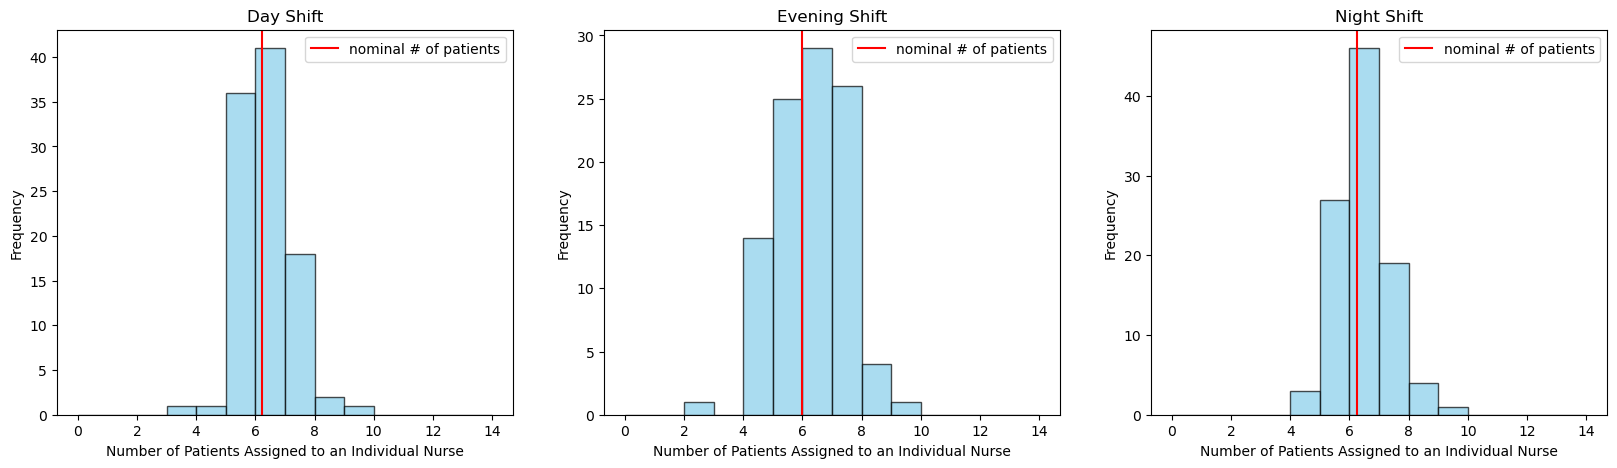

Worst-Case Number of Patients: [82.0, 46.0, 77.0]


In [138]:
nominal_vals = [nurse_count[0].X, nurse_count[1].X, nurse_count[2].X]
nominal_z = m.ObjVal
expected_patient_counts = [56, 30, 50]

day_samples = []
evening_samples = []
night_samples = []
samples = [day_samples, evening_samples, night_samples]
feasible_counts = [0, 0, 0]

n_samples = np.arange(100)

for i in range(n_shifts):
  for _ in n_samples:
    samples[i].append(poisson.rvs(mu=expected_patient_counts[i]) / nominal_vals[i])
    if samples[i][-1] <= nominal_z:
      feasible_counts[i] += 1

for s, shift in enumerate(shifts):
  print(f'{shift} shift feasibility rate for 100 samples: {feasible_counts[s]}%')

print(f'Average Feasibility: {sum(feasible_counts) / n_shifts:,.2f}%')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for c, ax in enumerate(axes):
  ax.hist(samples[c], np.arange(15), color='skyblue', edgecolor='black', alpha=0.7)
  ax.axvline(x=expected_patient_counts[c] / nominal_vals[c], color='red', 
             label='nominal # of patients')
  ax.legend()
  ax.set_xlabel("Number of Patients Assigned to an Individual Nurse")
  ax.set_ylabel("Frequency")
  ax.set_title(f"{shifts[c]} Shift")

plt.show()

max_vals = []
for s in range(n_shifts):
  max_vals.append(max(samples[s]) * nominal_vals[s])
print(f'Worst-Case Number of Patients: {max_vals}')

#### Worst-Case Scenario

In [82]:
worst_case_num_patients = [72, 42, 63]

rm = gp.Model('robust_lp')

# integer decision variables: the number of nurses assigned to each department
nurse_count = {}
for s, shift in enumerate(shifts):
    nurse_count[s] = rm.addVar(lb=0.0, vtype=GRB.INTEGER, name=f'{shift}')

# binary decision variables: three for every nurse (to cover all three departments)
nurses = []
for n in range(num_nurses):
    nurses.append([])
    for shift in shifts:
        nurses[n].append(rm.addVar(lb=0.0, vtype=GRB.BINARY, name=f'{n}_{shift}'))

# objective function: maximize minimum shift coverage
w = rm.addVar(lb=0.0, name="max_patients_per_nurse")

for s in range(n_shifts):
    rm.addConstr(
        worst_case_num_patients[s] <= w * gp.quicksum(nurses[n][s] for n in range(num_nurses))
    )

rm.setObjective(w, GRB.MINIMIZE)

# each nurse assigned to one shift
for n in range(num_nurses):
    rm.addConstr(gp.quicksum(nurses[n][s] for s in range(n_shifts)) == 1)

# link integer decision variables to binary decision variables
for s in range(n_shifts):
    rm.addConstr(nurse_count[s] == gp.quicksum(nurses[n][s] for n in range(num_nurses)))

rm.optimize()

# -----------------------------
# Results
# -----------------------------
if m.status == GRB.OPTIMAL:
    print("\n✅ Optimal solution found:")
    for s, shift in enumerate(shifts):
        print(f"  {shift} Shift: {math.ceil(nurse_count[s].X)} nurses")  # integer format
        print(f"     Nurse-to-Patient Ratio -> 1:{1/(nurse_count[s].X/worst_case_num_patients[s]):,.2f}")
    print(f"  Lowest Ratio -> 1:{1/(1/rm.ObjVal):,.2f}")
else:
    print(f"❌ Optimization ended with status {m.status}.")

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[x86] - Darwin 24.6.0 24G90)

CPU model: Intel(R) Core(TM) i7-9750H CPU @ 2.60GHz
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 25 rows, 70 columns and 135 nonzeros (Min)
Model fingerprint: 0x246984df
Model has 1 linear objective coefficients
Model has 3 quadratic constraints
Variable types: 1 continuous, 69 integer (66 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
  QRHS range       [4e+01, 7e+01]

Presolve removed 3 rows and 3 columns
Presolve time: 0.00s
Presolved: 157 rows, 265 columns, 462 nonzeros
Presolved model has 132 SOS constraint(s)
Variable types: 133 continuous, 132 integer (132 binary)
Found heuristic solution: objective 72.0000000
Found heuristic solution: objective 63.0000000
Found heuristic solution: object

#### Should Montefiore Nyack hire more nurses?

In [83]:
nominal_z = 3
print(nominal_z)
optimal_nurse_counts = {}
ratios = {}
for shift in shifts:
    optimal_nurse_counts[shift] = []
    ratios[shift] = []

for max_nurses in range(22, 50):
    hm = gp.Model('hiring_lp')

    # the number of nurses on each shift (integer variables)
    staffing = {}
    # how nurses are assigned to shifts (three binary variables for each nurse)
    assignments = {}
    # binary variables to capture whether or not additional nurses are hired
    hired = {}
    
    for s, shift in enumerate(shifts):
        staffing[s] = hm.addVar(lb=0.0, vtype=GRB.INTEGER, name=f'{shift}')

    for n in range(max_nurses):
        hired[n] = hm.addVar(lb=0.0, vtype=GRB.BINARY, name=f"nurse_{n}")
        assignments[n] = []
        for s in range(n_shifts):
            assignments[n].append(hm.addVar(vtype=GRB.BINARY, name=f"nurse_{n}_{shifts[s]}_shift"))

    # each nurse is assigned to one shift
    for n in range(max_nurses):
        hm.addConstr(
            gp.quicksum(assignments[n][s] for s in range(n_shifts)) == hired[n]
        )

    # linking assignment variables to staffing
    for s in range(n_shifts):
        hm.addConstr(
            gp.quicksum(assignments[n][s] for n in range(max_nurses)) == staffing[s]
        )
        hm.addConstr(
            staffing[s] >= math.ceil(patients[s] / nominal_z)
        )

    # minimize nurses needed
    hm.setObjective(
        gp.quicksum(hired[n] for n in range(max_nurses)),
        GRB.MINIMIZE
    )

    hm.optimize()

    # store results
    if hm.status == GRB.OPTIMAL:
        for s, shift in enumerate(shifts):
            optimal_nurse_counts[shift].append(math.ceil(staffing[s].X))
            ratios[shift].append(1/(staffing[s].X/patients[s]))
    else:
        print(f"❌ Optimization ended with status {hm.status}.")

print(optimal_nurse_counts)
print(ratios)

3
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[x86] - Darwin 24.6.0 24G90)

CPU model: Intel(R) Core(TM) i7-9750H CPU @ 2.60GHz
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 28 rows, 91 columns and 160 nonzeros (Min)
Model fingerprint: 0x92fb919d
Model has 22 linear objective coefficients
Variable types: 0 continuous, 91 integer (88 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+01, 2e+01]

Presolve removed 3 rows and 25 columns
Presolve time: 0.00s
Presolved: 25 rows, 66 columns, 132 nonzeros
Variable types: 0 continuous, 66 integer (66 binary)

Root relaxation: infeasible, 27 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 infeasible    0               -

#### Introducing Uncertainty

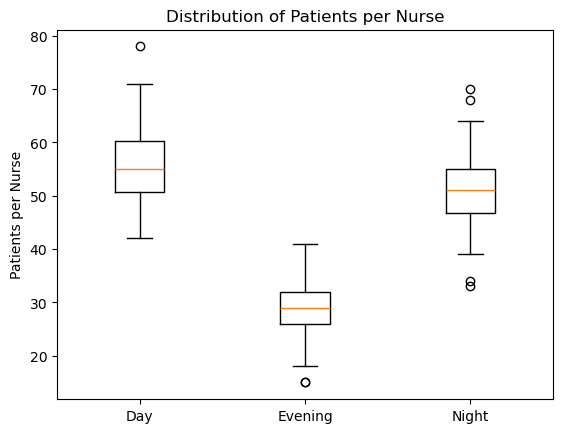

In [84]:
nominal_day = nurse_count[0].X
nominal_evening = nurse_count[1].X
nominal_night = nurse_count[2].X

day_patients = []
evening_patients = []
night_patients = []

for i in range(100):
  day_patients.append(np.random.poisson(patients[0]))
  evening_patients.append(np.random.poisson(patients[1]))
  night_patients.append(np.random.poisson(patients[2]))

data = [day_patients, evening_patients, night_patients]

plt.boxplot(data, labels=shifts)
plt.ylabel("Patients per Nurse")
plt.title("Distribution of Patients per Nurse")
plt.show()

#### Day Shift Patient Arrival Distribution